# C-MAPSS FD001 — Initial Exploration

Goal: load the FD001 training data, verify its shape matches the spec, give the columns human-readable names, and look at it with our own eyes before doing anything else.

Dataset reference: NASA C-MAPSS, FD001 subset (1 operating condition, 1 fault mode — easiest variant).

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display settings — make pandas show more columns and wider output
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

# Make matplotlib plots inline and reasonably sized
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Imports OK")

Imports OK


In [21]:
# Path to the raw data folder, relative to the notebook
DATA_RAW = Path('..') / 'data' / 'raw'

# Define column names per the C-MAPSS spec
index_cols = ['engine_id', 'cycle']
setting_cols = [f'setting_{i}' for i in range(1, 4)]
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
all_cols = index_cols + setting_cols + sensor_cols

print(f"Total columns expected: {len(all_cols)}")
print(f"Columns: {all_cols}")

Total columns expected: 26
Columns: ['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [22]:
train_path = DATA_RAW / 'train_FD001.txt'

train_fd001 = pd.read_csv(
    train_path,
    sep=r'\s+',
    header=None,
    names=all_cols,
)

print(f"Shape: {train_fd001.shape}")
print(f"Columns: {len(train_fd001.columns)}")
train_fd001.head()

Shape: (20631, 26)
Columns: 26


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [23]:
# Quick health check: dtypes and any missing values
print("Data types:")
print(train_fd001.dtypes)
print()
print(f"Missing values total: {train_fd001.isna().sum().sum()}")
print()
print(f"Number of unique engines: {train_fd001['engine_id'].nunique()}")
print(f"Engine IDs range: {train_fd001['engine_id'].min()} to {train_fd001['engine_id'].max()}")

Data types:
engine_id      int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17      int64
sensor_18      int64
sensor_19    float64
sensor_20    float64
sensor_21    float64
dtype: object

Missing values total: 0

Number of unique engines: 100
Engine IDs range: 1 to 100


Lifetimes summary (cycles per engine):
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


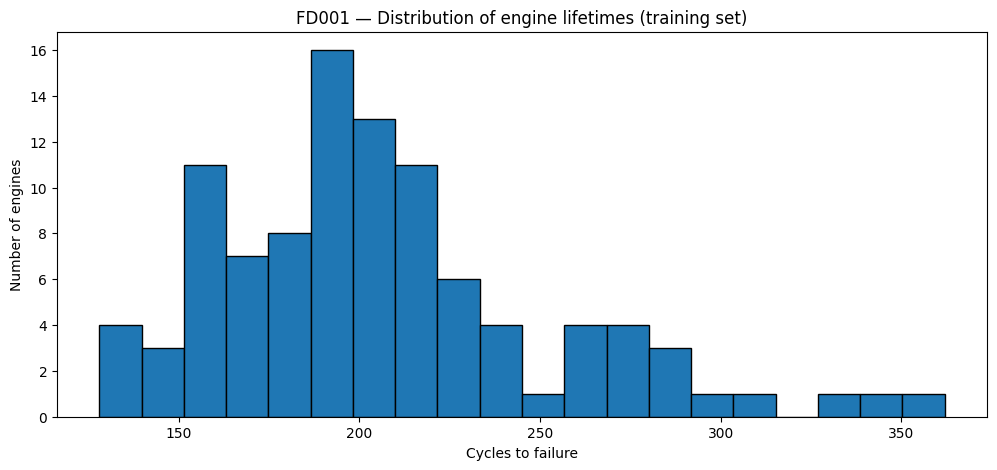

In [24]:
# For each engine, count how many cycles it ran before failing
engine_lifetimes = train_fd001.groupby('engine_id')['cycle'].max()

print(f"Lifetimes summary (cycles per engine):")
print(engine_lifetimes.describe())

# Plot the distribution
plt.figure()
plt.hist(engine_lifetimes, bins=20, edgecolor='black')
plt.xlabel('Cycles to failure')
plt.ylabel('Number of engines')
plt.title('FD001 — Distribution of engine lifetimes (training set)')
plt.show()

In [25]:
# Compute RUL for each row in training data
# Per engine: max_cycle (cycle at failure) − current_cycle = remaining cycles

train_fd001['RUL'] = (
    train_fd001.groupby('engine_id')['cycle'].transform('max')
    - train_fd001['cycle']
)

# Verify the shape didn't change and we just added a column
print(f"Shape after adding RUL: {train_fd001.shape}")
print()

# Sanity check on engine 1
engine_1 = train_fd001[train_fd001['engine_id'] == 1]
print(f"Engine 1: {len(engine_1)} cycles total")
print(f"First row (cycle 1): RUL = {engine_1.iloc[0]['RUL']}")
print(f"Last row (final cycle): RUL = {engine_1.iloc[-1]['RUL']}")
print()
print("First 3 rows of engine 1 (cycle, RUL):")
print(engine_1[['cycle', 'RUL']].head(3))
print()
print("Last 3 rows of engine 1 (cycle, RUL):")
print(engine_1[['cycle', 'RUL']].tail(3))

Shape after adding RUL: (20631, 27)

Engine 1: 192 cycles total
First row (cycle 1): RUL = 191.0
Last row (final cycle): RUL = 0.0

First 3 rows of engine 1 (cycle, RUL):
   cycle  RUL
0      1  191
1      2  190
2      3  189

Last 3 rows of engine 1 (cycle, RUL):
     cycle  RUL
189    190    2
190    191    1
191    192    0


In [26]:
# Load test sensor data — same format as train, no header, whitespace separated
test_path = DATA_RAW / 'test_FD001.txt'

test_fd001 = pd.read_csv(
    test_path,
    sep=r'\s+',
    header=None,
    names=all_cols,
)

# Load ground-truth RUL — one number per test engine, single column
rul_path = DATA_RAW / 'RUL_FD001.txt'

rul_fd001 = pd.read_csv(
    rul_path,
    sep=r'\s+',
    header=None,
    names=['RUL'],
)

print(f"Test set shape: {test_fd001.shape}")
print(f"Number of unique test engines: {test_fd001['engine_id'].nunique()}")
print()
print(f"Ground truth RUL shape: {rul_fd001.shape}")
print(f"First 5 ground-truth RUL values: {rul_fd001['RUL'].head().tolist()}")
print()

# How many cycles does each test engine have? (compare to train)
test_last_cycle = test_fd001.groupby('engine_id')['cycle'].max()
print("Test set engine cycle counts (how far into each engine's life we observed):")
print(test_last_cycle.describe())

Test set shape: (13096, 26)
Number of unique test engines: 100

Ground truth RUL shape: (100, 1)
First 5 ground-truth RUL values: [112, 98, 69, 82, 91]

Test set engine cycle counts (how far into each engine's life we observed):
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64


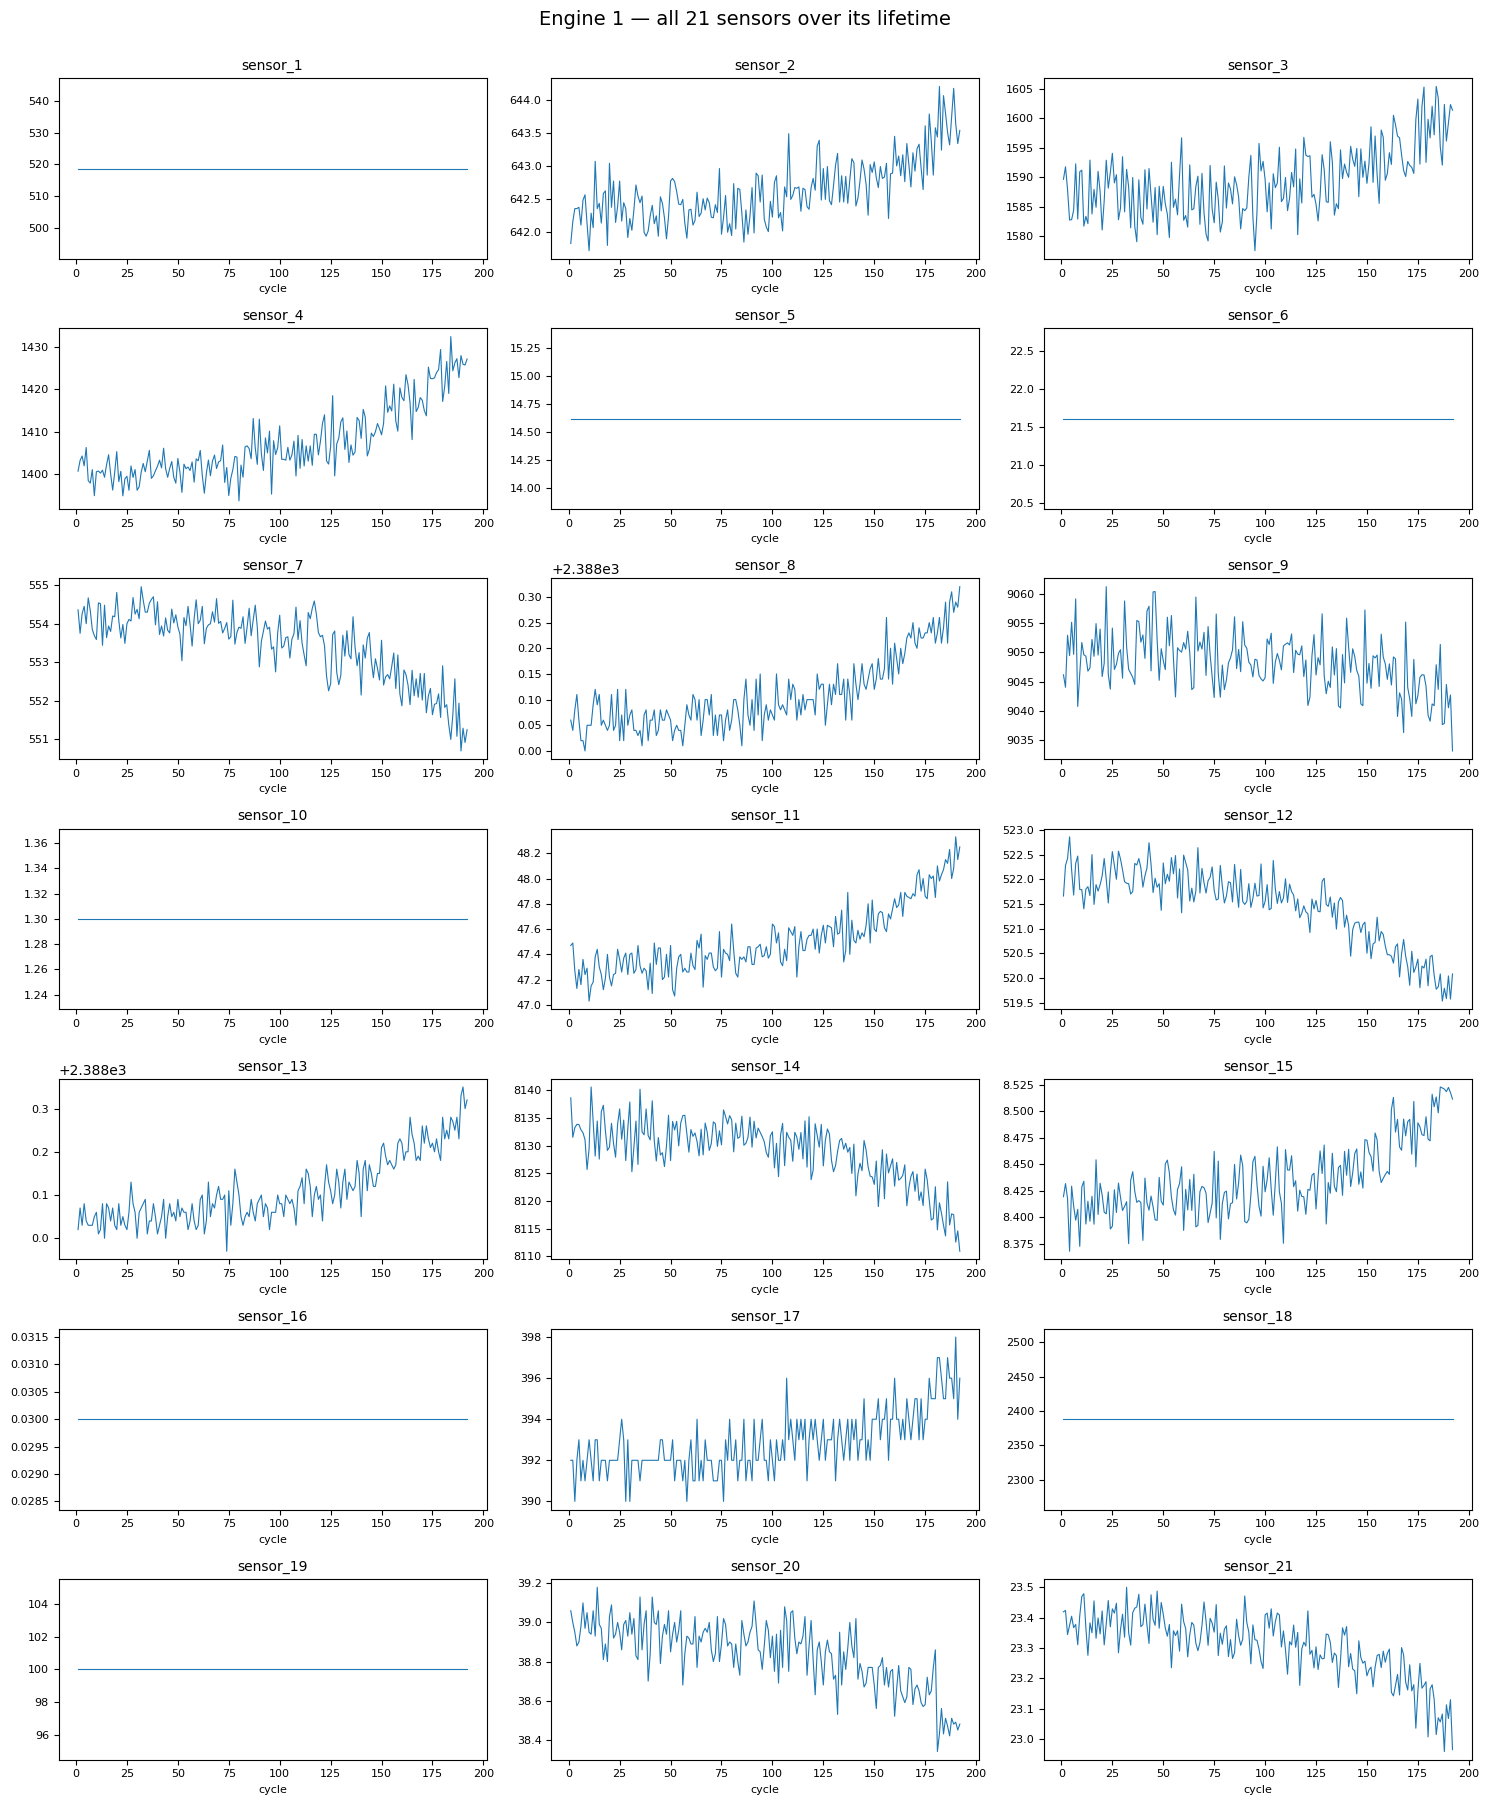

In [27]:
# Pick engine 1's full trajectory
engine_to_plot = 1
df_engine = train_fd001[train_fd001['engine_id'] == engine_to_plot]

# Create a grid of subplots — 21 sensors, arranged as 7 rows × 3 cols
fig, axes = plt.subplots(7, 3, figsize=(15, 18))
axes = axes.flatten()  # turn 7×3 grid into a flat list of 21 axes

for i, sensor in enumerate(sensor_cols):
    ax = axes[i]
    ax.plot(df_engine['cycle'], df_engine[sensor], linewidth=0.8)
    ax.set_title(sensor, fontsize=10)
    ax.set_xlabel('cycle', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(f'Engine {engine_to_plot} — all 21 sensors over its lifetime', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

In [28]:
# Compute per-sensor standard deviation across the entire FD001 training set.
# Sensors with std = 0 (or very near 0) are constant — physically inactive in FD001.

sensor_std = train_fd001[sensor_cols].std()
print("Sensor standard deviations (sorted ascending):")
print(sensor_std.sort_values().head(10))

# Threshold: anything with std < 0.001 we treat as effectively constant
constant_threshold = 0.01
constant_sensors = sensor_std[sensor_std < constant_threshold].index.tolist()
informative_sensors = [s for s in sensor_cols if s not in constant_sensors]

print()
print(f"Constant sensors (std < {constant_threshold}): {len(constant_sensors)}")
print(constant_sensors)
print()
print(f"Informative sensors: {len(informative_sensors)}")

Sensor standard deviations (sorted ascending):
sensor_1     0.000000e+00
sensor_10    0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    3.469531e-18
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
dtype: float64

Constant sensors (std < 0.01): 7
['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Informative sensors: 14


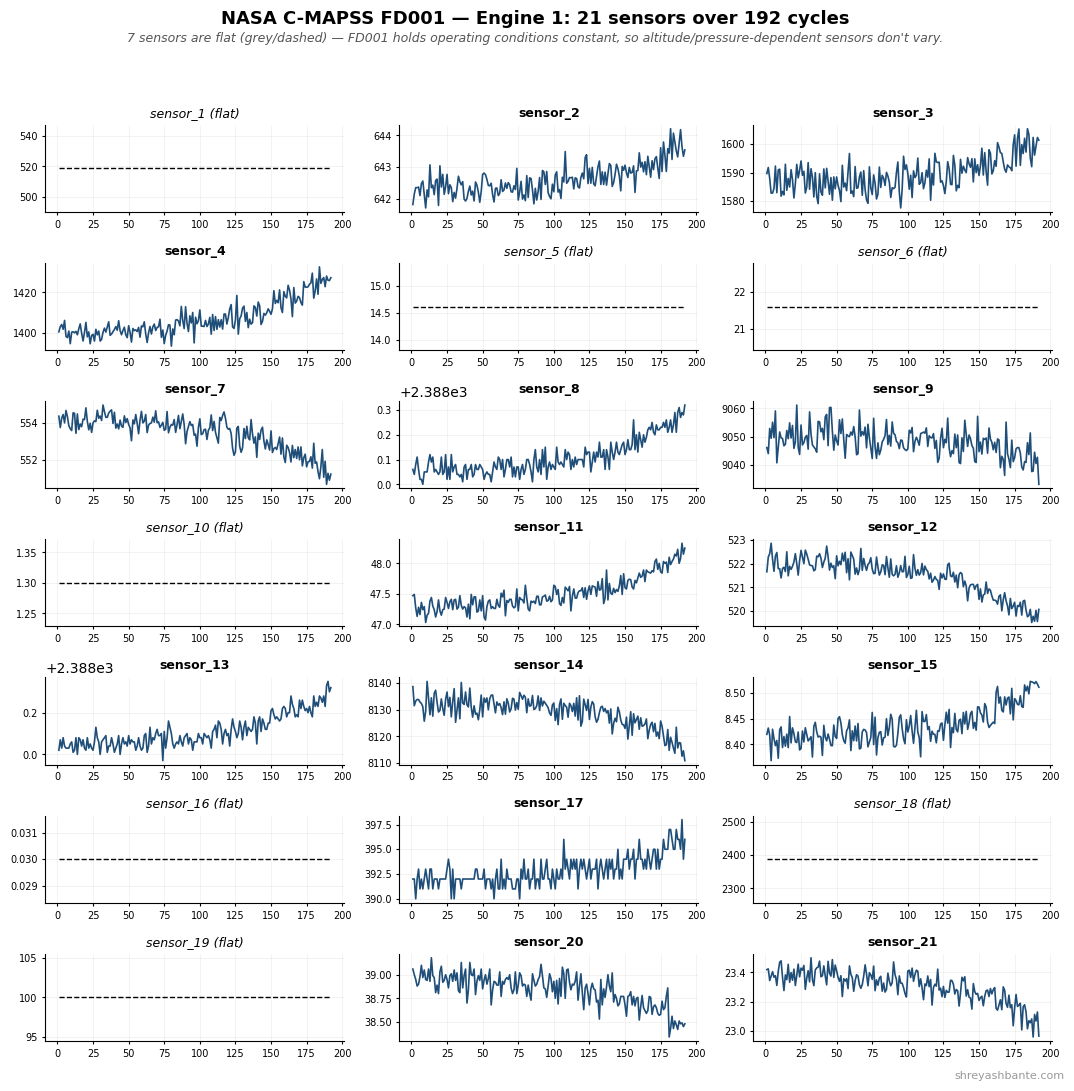

In [29]:
# LinkedIn-ready plot: engine 1, all 21 sensors, constants greyed out

import matplotlib.pyplot as plt
from pathlib import Path

# Use engine 1's full trajectory
engine_to_plot = 1
df_engine = train_fd001[train_fd001['engine_id'] == engine_to_plot].copy()

# Figure: square 1080x1080 → ~10.8 inches at 100 DPI
fig, axes = plt.subplots(
    7, 3,
    figsize=(10.8, 10.8),
    dpi=100,
)
axes = axes.flatten()

# Style choices
COLOR_TRENDING = '#1f4e79'   # deep blue, prints/screens cleanly
COLOR_CONSTANT = "#050000"   # darker grey — visible at thumbnail size
LINEWIDTH_TRENDING = 1.2
LINEWIDTH_CONSTANT = 1.0

for i, sensor in enumerate(sensor_cols):
    ax = axes[i]
    is_constant = sensor in constant_sensors
    color = COLOR_CONSTANT if is_constant else COLOR_TRENDING
    linewidth = LINEWIDTH_CONSTANT if is_constant else LINEWIDTH_TRENDING
    linestyle = '--' if is_constant else '-'

    ax.plot(
        df_engine['cycle'],
        df_engine[sensor],
        color=color,
        linewidth=linewidth,
        linestyle=linestyle,
    )

    # Title shows sensor name + a "(flat)" tag for constants
    # Both visible (black), distinguished by italic style for flat sensors
    title = f"{sensor} (flat)" if is_constant else sensor
    ax.set_title(
        title,
        fontsize=9,
        color='black',
        fontweight='bold' if not is_constant else 'normal',
        fontstyle='italic' if is_constant else 'normal',
    )

    # Minimal axis decoration — tiny ticks, no clutter
    ax.tick_params(labelsize=7, length=2)
    ax.grid(True, alpha=0.2, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Overall title + subtitle
fig.suptitle(
    f"NASA C-MAPSS FD001 — Engine {engine_to_plot}: 21 sensors over 192 cycles",
    fontsize=13, fontweight='bold', y=0.995,
)
fig.text(
    0.5, 0.965,
    "7 sensors are flat (grey/dashed) — FD001 holds operating conditions constant, so altitude/pressure-dependent sensors don't vary.",
    ha='center', fontsize=9, color='#555555', style='italic',
)

# Footer / attribution — small but present
fig.text(
    0.99, 0.005,
    "shreyashbante.com",
    ha='right', fontsize=8, color='#999999',
)

plt.tight_layout(rect=[0, 0.01, 1, 0.95])
plt.show()

In [30]:
# Save the plot to a publish-ready PNG
# Re-run the figure-building cell above first if you've changed kernel, otherwise plt's current figure is still in memory

output_dir = Path('D:\Production Projects\cmapss-rul\src') / 'plots'
output_dir.mkdir(exist_ok=True)

output_path = output_dir / 'fd001_engine1_all_sensors.png'

# Save the *current* figure (the one rendered by the cell above)
plt.savefig(
    output_path,
    dpi=120,
    bbox_inches='tight',
    facecolor='white',
)

print(f"Saved: {output_path.resolve()}")
print(f"File exists: {output_path.exists()}")
print(f"File size: {output_path.stat().st_size / 1024:.1f} KB")

Saved: D:\Production Projects\cmapss-rul\src\plots\fd001_engine1_all_sensors.png
File exists: True
File size: 5.0 KB


<Figure size 1200x500 with 0 Axes>

In [31]:
# Explicit modeling-feature schema for FD001.
# Single source of truth — every downstream cell derives from these lists.

id_cols = ['engine_id', 'cycle']
label_col = 'RUL'

# Sensors with std < 0.01 across FD001 train — physically inactive in this dataset.
# (Derived in cell 10, hardcoded here for clarity and downstream stability.)
constant_sensor_cols = [
    'sensor_1', 'sensor_5', 'sensor_6',
    'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19',
]

# Modeling features: 3 operational settings + the 14 informative sensors.
informative_sensor_cols = [s for s in sensor_cols if s not in constant_sensor_cols]
feature_cols = setting_cols + informative_sensor_cols

# --- Sanity checks (fail loudly if anything drifts) ---

# 1. No overlap between the four groups
all_groups = id_cols + [label_col] + constant_sensor_cols + feature_cols
assert len(all_groups) == len(set(all_groups)), \
    "Column overlap detected between id/label/constant/feature groups."

# 2. Every column in the DataFrame is accounted for
expected_full_set = set(id_cols) | {label_col} | set(constant_sensor_cols) | set(feature_cols)
actual_full_set = set(train_fd001.columns)
missing = actual_full_set - expected_full_set
extra = expected_full_set - actual_full_set
assert not missing, f"Columns in DataFrame not assigned to any group: {missing}"
assert not extra, f"Columns referenced but not in DataFrame: {extra}"

# 3. Feature count matches the locked target (3 settings + 14 sensors)
assert len(feature_cols) == 17, \
    f"Expected 17 feature columns, got {len(feature_cols)}."

# --- Report ---
print(f"id_cols              ({len(id_cols)}): {id_cols}")
print(f"label_col            (1): {label_col}")
print(f"constant_sensor_cols ({len(constant_sensor_cols)}): {constant_sensor_cols}")
print(f"feature_cols         ({len(feature_cols)}): {feature_cols}")
print()
print(f"Total columns covered: {len(all_groups)} (matches DataFrame: {len(actual_full_set)})")
print()
print("All assertions passed.")

id_cols              (2): ['engine_id', 'cycle']
label_col            (1): RUL
constant_sensor_cols (7): ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
feature_cols         (17): ['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Total columns covered: 27 (matches DataFrame: 27)

All assertions passed.


In [32]:
# Load test_FD001 and assign RUL is NOT needed — test set has no RUL labels.
# We need the LAST observed cycle per test engine — that's the prediction point.

# For each row, get its engine's maximum cycle
test_fd001['max_cycle'] = test_fd001.groupby('engine_id')['cycle'].transform('max')

# Keep only the rows where current cycle == max cycle (the last observed row per engine)
test_snapshots = test_fd001[test_fd001['cycle'] == test_fd001['max_cycle']].copy()

# Clean up: drop the helper column, sort by engine_id, reset index
test_snapshots = test_snapshots.drop(columns='max_cycle').sort_values('engine_id').reset_index(drop=True)

# --- Verify ---
print(f"Test snapshots shape: {test_snapshots.shape}")
print(f"Number of rows (should be 100, one per engine): {len(test_snapshots)}")
print(f"Unique engines: {test_snapshots['engine_id'].nunique()}")
print()
print("First 5 snapshot rows (engine_id, cycle — the last observed cycle per engine):")
print(test_snapshots[['engine_id', 'cycle']].head())
print()
print("Cycle stats for snapshot rows (these are the cut-off points):")
print(test_snapshots['cycle'].describe())

Test snapshots shape: (100, 26)
Number of rows (should be 100, one per engine): 100
Unique engines: 100

First 5 snapshot rows (engine_id, cycle — the last observed cycle per engine):
   engine_id  cycle
0          1     31
1          2     49
2          3    126
3          4    106
4          5     98

Cycle stats for snapshot rows (these are the cut-off points):
count    100.000000
mean     130.960000
std       53.593479
min       31.000000
25%       88.750000
50%      133.500000
75%      164.250000
max      303.000000
Name: cycle, dtype: float64


In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. The baseline prediction: mean of ALL training RUL labels
baseline_prediction = train_fd001['RUL'].mean()
print(f"Mean training RUL (our constant prediction): {baseline_prediction:.2f}")

# 2. Ground truth — load the 100 true RULs (one per test engine, in engine order)
#    (rul_fd001 was loaded earlier in cell 8)
y_true = rul_fd001['RUL'].values
print(f"Ground-truth RUL values: {len(y_true)} engines")
print(f"  range: {y_true.min()} to {y_true.max()}, mean: {y_true.mean():.2f}")

# 3. Predict the same constant for all 100 test engines
y_pred_baseline = np.full(shape=len(y_true), fill_value=baseline_prediction)

# 4. Compute RMSE
baseline_rmse = np.sqrt(mean_squared_error(y_true, y_pred_baseline))

print()
print(f"=== MEAN BASELINE RMSE: {baseline_rmse:.2f} cycles ===")
print()
print("This is the floor. Any real model must beat this.")

Mean training RUL (our constant prediction): 107.81
Ground-truth RUL values: 100 engines
  range: 7 to 145, mean: 75.52

=== MEAN BASELINE RMSE: 52.62 cycles ===

This is the floor. Any real model must beat this.


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# --- Build training matrices ---
X_train = train_fd001[feature_cols]      # 20631 x 17
y_train = train_fd001['RUL']             # 20631 RUL labels

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# --- Build test matrices (snapshot rows only) ---
X_test = test_snapshots[feature_cols]    # 100 x 17
y_true = rul_fd001['RUL'].values         # 100 ground-truth RULs, engine order

print(f"X_test shape: {X_test.shape}")
print(f"y_true shape: {y_true.shape}")
print()

# --- Train ---
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
print("Model trained.")

# --- Predict on test snapshots ---
y_pred = lin_reg.predict(X_test)

# --- Evaluate ---
lin_reg_rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print()
print(f"=== LINEAR REGRESSION TEST RMSE: {lin_reg_rmse:.2f} cycles ===")
print(f"(Mean baseline was 52.62 — improvement: {52.62 - lin_reg_rmse:.2f} cycles)")
print()

# --- Quick look at predictions vs truth for first 5 engines ---
print("First 5 engines — predicted vs true RUL:")
for i in range(5):
    print(f"  Engine {i+1}: predicted {y_pred[i]:6.1f}, true {y_true[i]:4d}, error {y_pred[i] - y_true[i]:+6.1f}")

X_train shape: (20631, 17)
y_train shape: (20631,)
X_test shape: (100, 17)
y_true shape: (100,)

Model trained.

=== LINEAR REGRESSION TEST RMSE: 32.04 cycles ===
(Mean baseline was 52.62 — improvement: 20.58 cycles)

First 5 engines — predicted vs true RUL:
  Engine 1: predicted  158.9, true  112, error  +46.9
  Engine 2: predicted  122.2, true   98, error  +24.2
  Engine 3: predicted   85.0, true   69, error  +16.0
  Engine 4: predicted   98.6, true   82, error  +16.6
  Engine 5: predicted  111.4, true   91, error  +20.4


In [35]:
import pandas as pd

# Pair each feature with its learned coefficient
coefficients = pd.DataFrame({
    'feature': feature_cols,
    'weight': lin_reg.coef_,
})

# Sort by absolute weight to see the "most influential" features first
coefficients['abs_weight'] = coefficients['weight'].abs()
coefficients = coefficients.sort_values('abs_weight', ascending=False).reset_index(drop=True)

print(f"Intercept (bias): {lin_reg.intercept_:.2f}")
print()
print("Feature weights, sorted by magnitude:")
print(coefficients[['feature', 'weight']].to_string(index=False))

Intercept (bias): 65103.95

Feature weights, sorted by magnitude:
  feature        weight
setting_2  1.517475e+03
sensor_15 -1.200705e+02
setting_1  5.213063e+01
sensor_21  4.109149e+01
sensor_11 -3.732312e+01
sensor_20  1.991692e+01
 sensor_8 -1.328456e+01
sensor_13 -1.226835e+01
sensor_12  1.063639e+01
 sensor_7  6.906180e+00
 sensor_2 -6.820832e+00
sensor_17 -1.853109e+00
 sensor_4 -7.658162e-01
 sensor_3 -4.394370e-01
 sensor_9 -3.494796e-01
sensor_14 -2.731797e-01
setting_3 -1.018514e-09


In [36]:
pd.Series(lin_reg.coef_, index=feature_cols).abs().sort_values(ascending=False)

setting_2    1.517475e+03
sensor_15    1.200705e+02
setting_1    5.213063e+01
sensor_21    4.109149e+01
sensor_11    3.732312e+01
sensor_20    1.991692e+01
sensor_8     1.328456e+01
sensor_13    1.226835e+01
sensor_12    1.063639e+01
sensor_7     6.906180e+00
sensor_2     6.820832e+00
sensor_17    1.853109e+00
sensor_4     7.658162e-01
sensor_3     4.394370e-01
sensor_9     3.494796e-01
sensor_14    2.731797e-01
setting_3    1.018514e-09
dtype: float64

In [37]:
# Rebuild predictions in case the kernel was restarted
# (Skip this cell if y_pred and y_true are still in memory from Wednesday)

from sklearn.linear_model import LinearRegression

X_train = train_fd001[feature_cols]
y_train = train_fd001['RUL']
X_test = test_snapshots[feature_cols]
y_true = rul_fd001['RUL'].values

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

print(f"Predictions: {len(y_pred)} engines")
print(f"y_pred range: {y_pred.min():.1f} to {y_pred.max():.1f}")
print(f"y_true range: {y_true.min()} to {y_true.max()}")

Predictions: 100 engines
y_pred range: -8.9 to 186.1
y_true range: 7 to 145


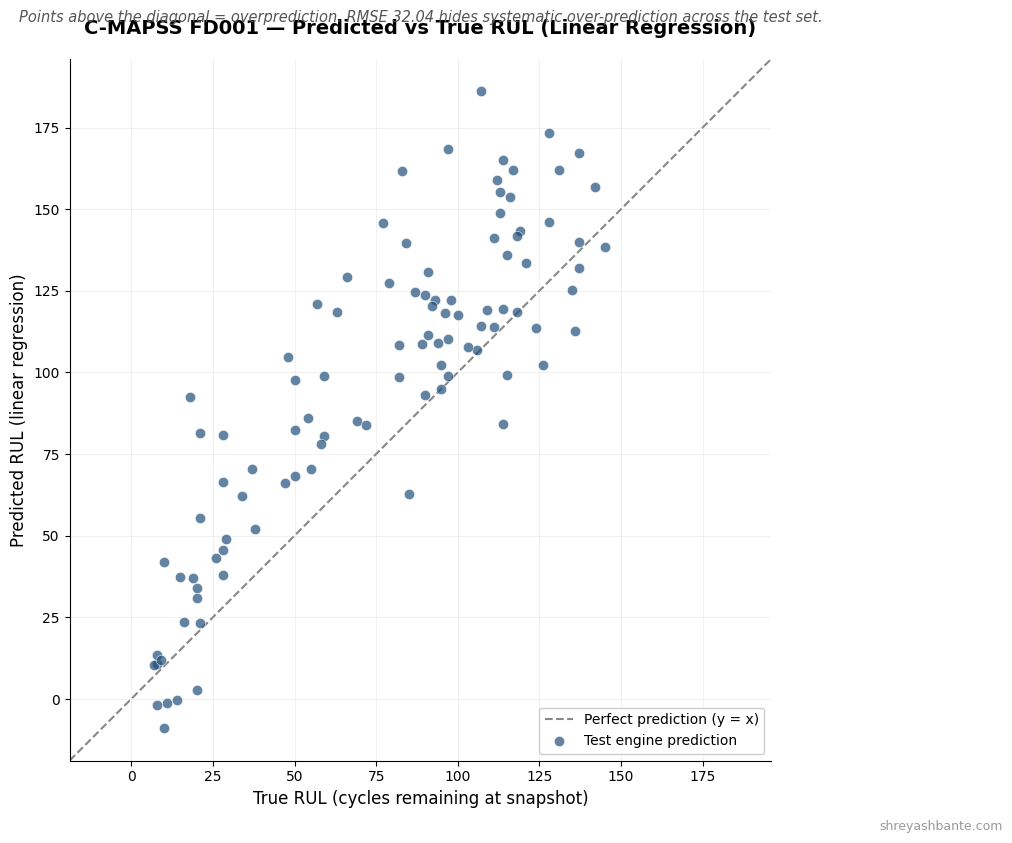

In [38]:
import matplotlib.pyplot as plt
import numpy as np

# Figure: LinkedIn-friendly 1200x900 at 100dpi → 12 x 9 inches
fig, ax = plt.subplots(figsize=(12, 9), dpi=100)

# Determine plot range — symmetric around the data so the diagonal fills the frame
plot_min = min(y_true.min(), y_pred.min()) - 10
plot_max = max(y_true.max(), y_pred.max()) + 10

# Diagonal y=x reference line first (so it sits behind the dots)
ax.plot(
    [plot_min, plot_max], [plot_min, plot_max],
    linestyle='--', color='#888888', linewidth=1.5, zorder=1,
    label='Perfect prediction (y = x)',
)

# The 100 engine predictions
ax.scatter(
    y_true, y_pred,
    s=55, color='#1f4e79', alpha=0.7, edgecolor='white', linewidth=0.5,
    zorder=2, label='Test engine prediction',
)

# Axis limits + labels
ax.set_xlim(plot_min, plot_max)
ax.set_ylim(plot_min, plot_max)
ax.set_aspect('equal')   # critical: equal aspect so the diagonal is actually 45°

ax.set_xlabel('True RUL (cycles remaining at snapshot)', fontsize=12)
ax.set_ylabel('Predicted RUL (linear regression)', fontsize=12)

# Title + subtitle
ax.set_title(
    "C-MAPSS FD001 — Predicted vs True RUL (Linear Regression)",
    fontsize=14, fontweight='bold', pad=18,
)
fig.text(
    0.5, 0.91,
    "Points above the diagonal = overprediction. RMSE 32.04 hides systematic over-prediction across the test set.",
    ha='center', fontsize=10.5, color='#555555', style='italic',
)

# Clean up chart junk
ax.grid(True, alpha=0.25, linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10)

# Legend
ax.legend(loc='lower right', fontsize=10, frameon=True, framealpha=0.95)

# Watermark — bottom-right, subtle
fig.text(
    0.985, 0.012,
    "shreyashbante.com",
    ha='right', fontsize=9, color='#999999',
)

plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

In [40]:
import numpy as np
from sklearn.metrics import mean_squared_error

# y_pred from Wednesday's linear regression is still in memory.
# (If kernel restarted, re-run the regenerate-predictions cell first.)

# Clip predictions: anything below 0 becomes 0. Upper bound stays free.
y_pred_clipped = np.clip(y_pred, a_min=0, a_max=None)

# Count how many predictions were affected
num_clipped = (y_pred < 0).sum()
print(f"Predictions clipped (were negative): {num_clipped} out of {len(y_pred)}")
print(f"y_pred_clipped range: {y_pred_clipped.min():.1f} to {y_pred_clipped.max():.1f}")
print()

# Recompute RMSE with clipped predictions
lin_reg_rmse_clipped = np.sqrt(mean_squared_error(y_true, y_pred_clipped))

print(f"Original linear regression RMSE: 32.04 cycles")
print(f"=== CLIPPED LINEAR REGRESSION RMSE: {lin_reg_rmse_clipped:.2f} cycles ===")
print(f"Improvement from clipping: {32.04 - lin_reg_rmse_clipped:.2f} cycles")

Predictions clipped (were negative): 4 out of 100
y_pred_clipped range: 0.0 to 186.1

Original linear regression RMSE: 32.04 cycles
=== CLIPPED LINEAR REGRESSION RMSE: 31.99 cycles ===
Improvement from clipping: 0.05 cycles


In [41]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Create capped training labels
RUL_CAP = 125
y_train_capped = np.minimum(train_fd001['RUL'], RUL_CAP)

# Quick sanity on the cap
print(f"Original y_train range: {train_fd001['RUL'].min()} to {train_fd001['RUL'].max()}")
print(f"Capped y_train range:   {y_train_capped.min()} to {y_train_capped.max()}")
print(f"Rows affected by cap:   {(train_fd001['RUL'] > RUL_CAP).sum()} out of {len(train_fd001)}")
print(f"Percentage capped:      {(train_fd001['RUL'] > RUL_CAP).mean() * 100:.1f}%")
print()

# 2. Retrain linear regression with capped labels (same feature matrix X_train)
lin_reg_capped = LinearRegression()
lin_reg_capped.fit(X_train, y_train_capped)

# 3. Predict on test snapshots
y_pred_capped = lin_reg_capped.predict(X_test)

# 4. Clip predictions to [0, 125] — model was trained on labels in [0, 125], so out-of-range outputs are out-of-distribution
y_pred_capped_clipped = np.clip(y_pred_capped, a_min=0, a_max=RUL_CAP)

# 5. Evaluate vs UNCAPPED ground truth
capped_rmse = np.sqrt(mean_squared_error(y_true, y_pred_capped_clipped))

print(f"Baseline (mean prediction):           52.62 cycles")
print(f"Raw linear regression:                32.04 cycles")
print(f"Raw LR + clip negatives to 0:         31.99 cycles")
print(f"=== CAPPED LR @ 125 + clip [0,125]:   {capped_rmse:.2f} cycles ===")
print()
print(f"Improvement vs raw LR: {32.04 - capped_rmse:.2f} cycles")
print(f"Total improvement vs mean baseline: {52.62 - capped_rmse:.2f} cycles ({(1 - capped_rmse/52.62)*100:.1f}%)")

Original y_train range: 0 to 361
Capped y_train range:   0 to 125
Rows affected by cap:   8031 out of 20631
Percentage capped:      38.9%

Baseline (mean prediction):           52.62 cycles
Raw linear regression:                32.04 cycles
Raw LR + clip negatives to 0:         31.99 cycles
=== CAPPED LR @ 125 + clip [0,125]:   21.70 cycles ===

Improvement vs raw LR: 10.34 cycles
Total improvement vs mean baseline: 30.92 cycles (58.8%)


In [45]:
import pandas as pd

capped_coefficients = pd.DataFrame({
    'feature': feature_cols,
    'weight': lin_reg_capped.coef_,
})
capped_coefficients['abs_weight'] = capped_coefficients['weight'].abs()
capped_coefficients = capped_coefficients.sort_values('abs_weight', ascending=False).reset_index(drop=True)

print(f"CAPPED model intercept: {lin_reg_capped.intercept_:.2f}")
print(f"(Original model intercept was 65103.95)")
print()
print("Capped model weights, sorted by magnitude:")
print(capped_coefficients[['feature', 'weight']].to_string(index=False))

CAPPED model intercept: 86588.71
(Original model intercept was 65103.95)

Capped model weights, sorted by magnitude:
  feature        weight
setting_2  3.080419e+02
sensor_15 -8.702598e+01
sensor_21  2.247442e+01
sensor_11 -2.237625e+01
sensor_13 -1.880972e+01
 sensor_8 -1.603872e+01
sensor_20  1.372691e+01
setting_1 -1.300203e+01
sensor_12  7.186444e+00
 sensor_7  4.664765e+00
 sensor_2 -4.560841e+00
sensor_17 -1.285268e+00
 sensor_4 -4.617035e-01
 sensor_3 -2.831634e-01
 sensor_9 -2.757388e-01
sensor_14 -2.246620e-01
setting_3 -2.069585e-10
